In [2]:
import pandas as pd

In [3]:
a = pd.read_csv('train_data.csv')

C:\Users\aria9\AppData\Local\Temp\ipykernel_12328\2196477119.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  a = pd.read_csv('train_data.csv')


In [4]:
a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 838944 entries, 0 to 838943
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   overall         838944 non-null  int64 
 1   vote            191468 non-null  object
 2   verified        838944 non-null  bool  
 3   reviewTime      838944 non-null  object
 4   reviewerID      838944 non-null  object
 5   asin            838944 non-null  object
 6   style           490613 non-null  object
 7   reviewerName    838717 non-null  object
 8   reviewText      838944 non-null  object
 9   summary         838868 non-null  object
 10  unixReviewTime  838944 non-null  int64 
dtypes: bool(1), int64(2), object(8)
memory usage: 64.8+ MB


### 1 - the chart. the solution to "کلاس های متوازن" is to give weights to the model or do under sampling

<function matplotlib.pyplot.show(close=None, block=None)>

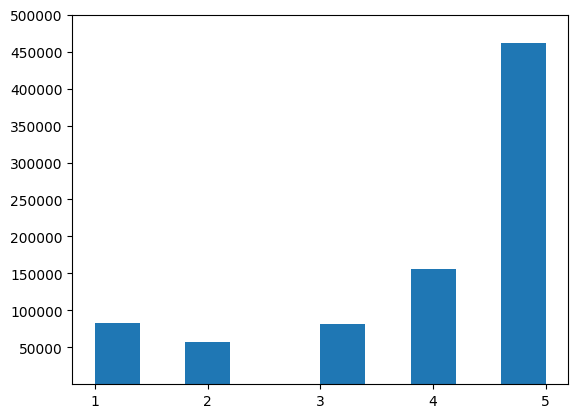

In [5]:
import matplotlib.pyplot as mlt
import numpy as np
mlt.hist(a['overall'])
mlt.xticks([1,2,3,4,5])
mlt.yticks(np.arange(50000,550000,50000))
mlt.show




##### Under sampling

In [4]:
rating = [1,2,3,4,5]
newdata = []

for r in rating:
    ans = a[a['overall']==r]
    ans = ans.sample(n=50000)
    newdata.append(ans)
    
a = pd.concat(newdata)



### -2 World cloud

1


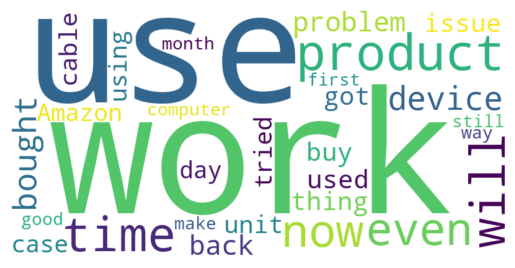

2


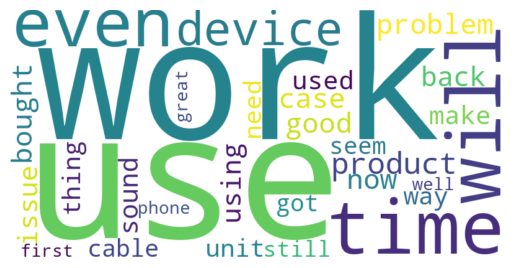

3


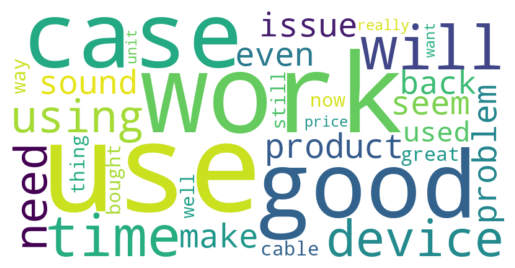

4


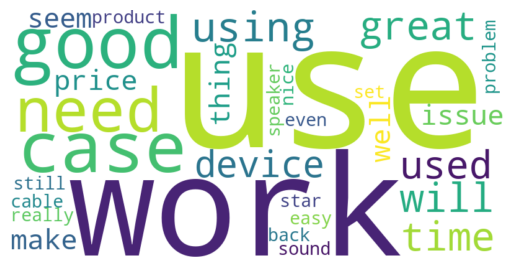

5


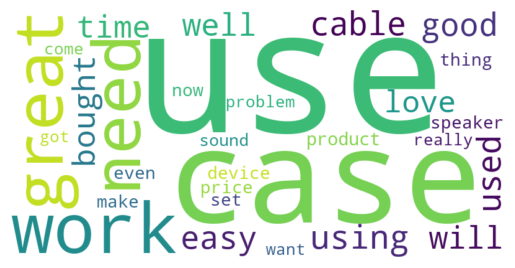

In [ ]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

ratings = [1,2,3,4,5]
words = []
sw = ['one','camera']
for i in sw:
    STOPWORDS.add(i)


for r in ratings:
    text = " ".join(a[a['overall'] == r]['reviewText'].astype(str))
    
    wordc = WordCloud(width=800,height=400,background_color='white',stopwords=STOPWORDS,max_words=30).generate(text)
    words.append(wordc)
    print(r)
    plt.imshow(wordc, interpolation='bilinear')
    plt.axis('off')
    plt.show()
    

### 3- most upvoted user

In [3]:
a.loc[a['vote'].isna(),'vote'] = 0
a['vote'] = a['vote'].str.replace(',', '')
a['vote'] = a['vote'].astype('float')

In [4]:
q3 = a.groupby('reviewerID').agg({'vote':'sum','reviewerName' : 'first'})
q3.sort_values(by='vote',ascending=False)
q3.reset_index(drop=True,inplace=True)
q3.set_index('reviewerName',inplace=True)
q3.sort_values(ascending=False,by='vote',inplace=True)
q3

,vote
reviewerName,
Benson Leung,4345.0
Voltron00x,3096.0
nycebo,2978.0
Mayra S.,2605.0
Cthulhu,2605.0
...,...
John Conkeroo,0.0
Sofia,0.0
VickyD,0.0


### 4- reviewtext length chart

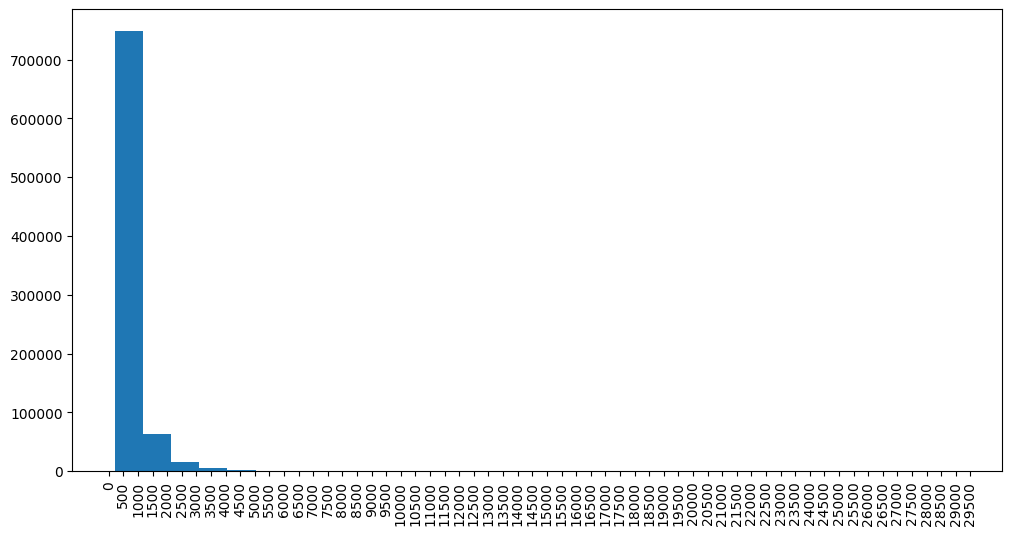

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
q4 = a.copy()
q4['len'] = q4['reviewText'].apply(lambda x : len(x))
plt.figure(figsize=(12,6))
plt.hist(q4['len'],bins=30)
plt.xticks(np.arange(0,30000,500),rotation=90)
plt.show()
#=====================================
#             unfiltered one
#=====================================

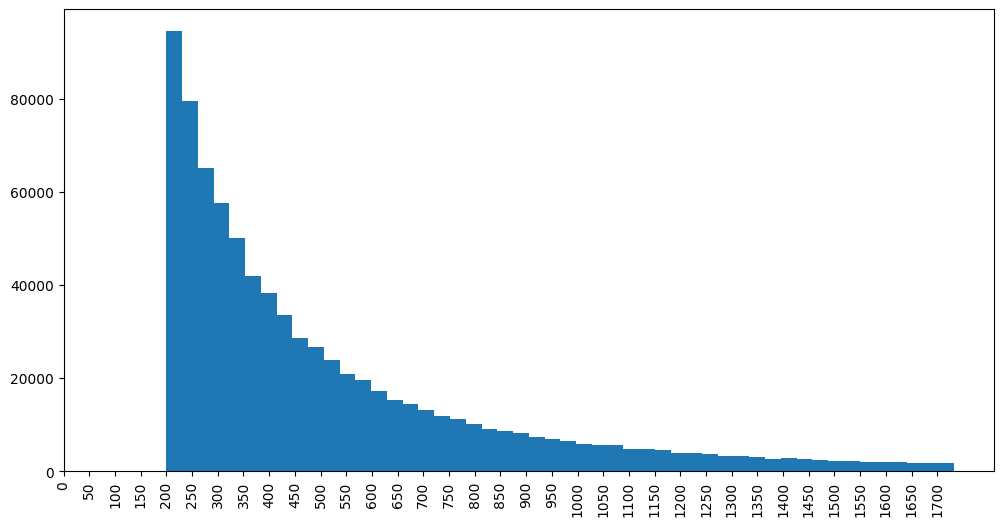

In [ ]:
limit = np.quantile(q4['len'], 0.95)
q4_filtered = q4[q4['len'] <= limit]

plt.figure(figsize=(12,6))
plt.hist(q4_filtered['len'], bins=50)
plt.xticks(np.arange(0, limit+1, 50), rotation=90)
plt.show()
#=====================================
#             filtered one
#=====================================


### 5- Top 5 products

In [12]:
ll = pd.read_csv('title_brand.csv')
q5 = pd.merge(a,ll,on='asin',how='left')
q5 = q5.groupby(['asin','overall']).agg(fivestar_count=('overall', 'count'),   
    brand_name=('brand', 'first'),       
    product_title=('title', 'first'))
q5 = q5.loc[(slice(None), 5), :].reset_index(drop=True)
q5.set_index('brand_name',inplace=True)
q5.sort_values('fivestar_count',ascending=False).head(10)

,fivestar_count,product_title
brand_name,,
Cambridge Soundworks,1163,OontZ Angle 3 Enhanced Stereo Edition IPX5 Spl...
NETGEAR,659,NETGEAR N300 WiFi Range Extender (EX2700)
Roku,600,Roku Streaming Stick (3600R) - HD Streaming Pl...
StarTech,598,StarTech USB 2.0 to SATA IDE Adapter (USB2SATA...
Logitech,552,Logitech M570 Wireless Trackball Mouse &ndash;...
Samsung,529,Samsung 850 EVO 500GB 2.5-Inch SATA III Intern...
NETGEAR,482,NETGEAR 5-Port Gigabit Ethernet Unmanaged Swit...
Asus,471,ASUS Tri-Band Gigabit (AC3200) WiFi Router (Up...
VideoSecu,448,VideoSecu ML531BE TV Wall Mount for Most 27&qu...


### 6- Most commented brand

In [16]:
q6 = pd.merge(a,ll,on='asin',how='left')
q6 = q6.groupby('brand').agg(average_score=('overall', 'mean'),   
    total_reviews=('overall', 'count'))
q6.sort_values(by='total_reviews',ascending=False).head(10)

,average_score,total_reviews
brand,,
Logitech,3.954061,17066
Samsung,3.941268,15409
AmazonBasics,4.201468,13213
Sony,3.938726,12436
Asus,3.855550,11928
Anker,4.244320,9860
TP-LINK,3.928681,9773
SanDisk,3.958810,8400
Sabrent,4.028005,7320
